Information Assurance Project

In [1]:
import pandas as pd
import numpy as np
from time import time
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn import svm, preprocessing
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# path="/home/Documents/CPS/ML_CRPS/16Bit/CSV/"
path="/content/drive/MyDrive/project/ML_CRPS/128Bit/CSV"

Mounted at /content/drive


In [3]:
import os
os.listdir(path)

['128_Challenge_1lakh.csv',
 '128_Challenge_180K.csv',
 '128_Challenge_85000.csv',
 '128_Responses_3bit_1lakh.csv',
 '128_Responses_4bit_85000.csv',
 'pranesh',
 'onetwoeight_Responses_4bit_85000.csv',
 'onetwoeight_Challenge_85k.csv',
 'onetwoeight_Challenge_85k_1.csv']

In [4]:
# names=["Bit0", "Bit1", "Bit2", "Bit3", "Bit4", "Bit5", "Bit6", "Bit7", "Bit8", "Bit9", "Bit10", "Bit11", "Bit12", "Bit13", "Bit14", "Bit15" ]
challengeDf = pd.read_csv(path+'/onetwoeight_Challenge_85k_1.csv', header=None)

responseDf = pd.read_csv(path+'/onetwoeight_Responses_4bit_85000.csv', header=None)

responsebits = 4

responseDf['output']  = responseDf[0].astype(str)
for i in range(1, responsebits):
    responseDf['output']  += responseDf[i].astype(str)
print(responseDf['output'].head())

0    0000
1    0010
2    1010
3    1000
4    0010
Name: output, dtype: object


In [5]:
X = np.array(challengeDf)
test_classes = {'0000':0, '0001':1, '0010':2, '0011':3, '0100':4, '0101':5, '0110':6,
                '0111':7, '1000':8, '1001':9, '1010':10, '1011':11, '1100':12, '1101':13, '1110':14, '1111':15}
#test_classes = {'000':0, '001':1, '010':2, '011':3, '100':4, '101':5, '110':6, '111':7}
#test_classes = {'00':0, '01':1, '10':2, '11':3}
#test_classes = {'0':0, '1':1}
col_y = []
for cl in np.array(responseDf['output'].values):
 col_y.append(test_classes[cl])
y = np.array(col_y)
print(X[0], y[0])
print(X.shape)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)


[0 1 1 0 1 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 0 1 0 0 1 0
 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 0
 1 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 1 1 1
 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 1 0] 0
(85000, 128)
(85000,)


In [6]:
# For plotting
import plotly.io as plt_io
import plotly.graph_objects as go
%matplotlib inline
from sklearn.preprocessing import StandardScaler

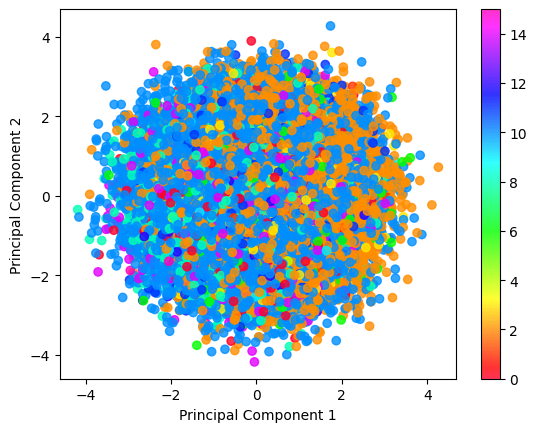

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


#### PLOT DATASET ####
# Project the data onto the 2 primary principal components
X = StandardScaler().fit_transform(X)
pca = PCA(2)
X_projected = pca.fit_transform(X)

x1 = X_projected[:, 0]
x2 = X_projected[:, 1]

fig = plt.figure()
plt.scatter(x1, x2,
        c=col_y, alpha=0.8,
        cmap='gist_rainbow')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar()

plt.show()

In [8]:
pip install umap-learn

In [9]:
import umap
import time

In [10]:
mapper = umap.UMAP().fit(X)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [11]:
!pip install umap-learn[plot] --quiet
import umap.plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 70.4 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))
/usr/local/lib/python3.11/dist-packages/numba/np/ufunc/dufunc.py:343: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,

<Axes: >

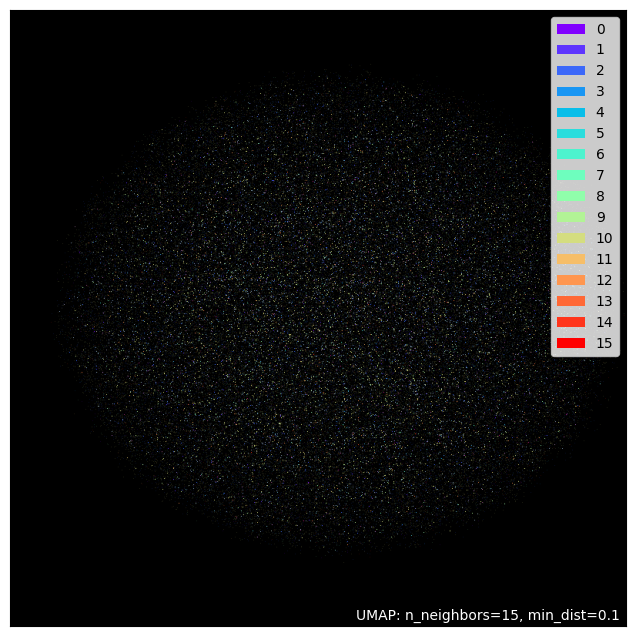

In [12]:
umap.plot.points(mapper,labels=y, theme='fire')

In [13]:
# import packages
import numpy as np
import pandas as pd

from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from hyperopt import tpe, hp, fmin, STATUS_OK,Trials
from hyperopt.pyll.base import scope
from hyperopt import fmin, hp, tpe, Trials, space_eval
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [14]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    return accuracy

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def get_scores(model_clf,X_test,save=False,title_addon="",
    path="",anomaly="anomaly"):
    y_true = df_test[anomaly]
    y_pred = df_test[model_name]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn+fp)
    recall_score=tp/(tp+fn)
    iou_data=iou(y_true,y_pred)
    f1_score_data=f1_score(y_true,y_pred)
    recall_Data=recall(y_true,y_pred)
    precision_data=precision(y_true,y_pred)
    roc_auc_score_data=roc_auc_score(y_true=y_true, y_score=y_pred)
    scores_dict={"iou_data":iou_data,"f1_score_data":f1_score_data,"recall_Data":recall_Data, "precision_data":precision_data,"calc_recall":recall_score,"calc_specificity":specificity,"roc_auc_score_data":roc_auc_score_data}
    if save:
         df_result=pd.DataFrame.from_dict(scores_dict,orient="index").T
         df_result.to_csv(path+"/scores/"
         +model_name+title_addon+".csv")
         return scores_dict

Logistic Regression

In [15]:
#check space
from sklearn.linear_model import LogisticRegression
from hyperopt import hp
import time
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score
start = time.time()
#space = {
#          "solvers" : hp.choice("solvers", ['newton-cg', 'lbfgs', 'liblinear']),
#          "penalty" : hp.choice("penalty", ['l2']),
#          "C" : hp.choice("C", [10, 1.0, 0.1, 0.01])
#}
space = {
             'warm_start' : hp.choice('warm_start', [True, False]),
             'fit_intercept' : hp.choice('fit_intercept', [True, False]),
             'tol' : hp.uniform('tol', 0.00001, 0.0001),
             'C' : hp.uniform('C', 0.001, 10),
             'solver' : hp.choice('solver', ['newton-cg', 'lbfgs', 'liblinear']),
             'max_iter' : hp.choice('max_iter', range(100,1000)),
             'multi_class' : 'auto',
             'class_weight' : 'balanced'
      }
# define objective function
def model(params):
  model_clf=LogisticRegression(**params,n_jobs=-1)
  return model_clf

def hyperparameter_tuning(params):
     clf = model(params)
     acc = cross_val_score(clf, X_train, y_train,scoring="accuracy").mean()
     return {"loss": -acc, "status": STATUS_OK}

In [16]:
pip install Trials

In [17]:
# Initialize trials object
trials = Trials()

best = fmin(
    fn=hyperparameter_tuning,
    space = space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials
)

print("Best: {}".format(best))
clf_optimised = model(space_eval(space, best)).fit(X_train, y_train)
# Calculating performance on validation set
# clf_optimised_val_score = roc_auc_score(y_test, clf_optimised.predict_proba(X_test)[:, 1])
clf_optimised_val_score = accuracy(y_test, clf_optimised.predict(X_test))*100
print('Cross-val score: {0:.5f}; validation score: {1:.5f}'.\
      format(-trials.best_trial['result']['loss']*100, clf_optimised_val_score))
print('Best parameters:')
print(space_eval(space, best))
stop = time.time()
#print("Training time: {stop - start}s")
#print('Accuracy:', accuracy_score(y_test, clf_optimised.predict(X_test)))
#print('F1 score:', f1_score(y_test, clf_optimised.predict(X_test)))
#print('Recall:', recall_score(y_test, clf_optimised.predict(X_test)))
#print('Precision:', precision_score(y_test, clf_optimised.predict(X_test)))
#print('\n clasification report:\n', classification_report(y_test,clf_optimised.predict(X_test)))
#print('\n confussion matrix:\n',confusion_matrix(y_test, clf_optimised.predict(X_test)))

100%|██████████| 10/10 [23:32<00:00, 141.26s/trial, best loss: -0.9014264705882354]
Best: {'C': np.float64(8.94822790416416), 'fit_intercept': np.int64(0), 'max_iter': np.int64(519), 'solver': np.int64(1), 'tol': np.float64(5.606826023267861e-05), 'warm_start': np.int64(0)}
Cross-val score: 90.14265; validation score: 89.94706
Best parameters:
{'C': 8.94822790416416, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 619, 'multi_class': 'auto', 'solver': 'lbfgs', 'tol': 5.606826023267861e-05, 'warm_start': True}


In [18]:
print('Accuracy:', accuracy_score(y_test, clf_optimised.predict(X_test)))

Accuracy: 0.8994705882352941


In [19]:
import seaborn as sns
def plot_cm(y_true, y_pred, figsize=(16,16),title="logistic regression_0_1_85__128_4",path="/content/drive/MyDrive/project/logisticregression/",file_name="logistic regression_pran_0_1__85_128_4",save=True):
    if len(np.unique(y_pred))>len(np.unique(y_true)):
        ind=np.unique(y_pred)
    else:
        ind=np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=ind)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)

    cm = pd.DataFrame(cm, index=ind, columns=ind)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
    plt.title(title)
    sns.heatmap(cm, cmap= "YlGnBu", annot=annot, fmt='', ax=ax)
    df_cla=pd.DataFrame(classification_report(y_true, y_pred,output_dict=True)).T
    if save:
        df_cla.to_csv(path+"/report/"+title+file_name+".csv")
        plt.savefig(path+"/matrix/"+title+file_name+".png")


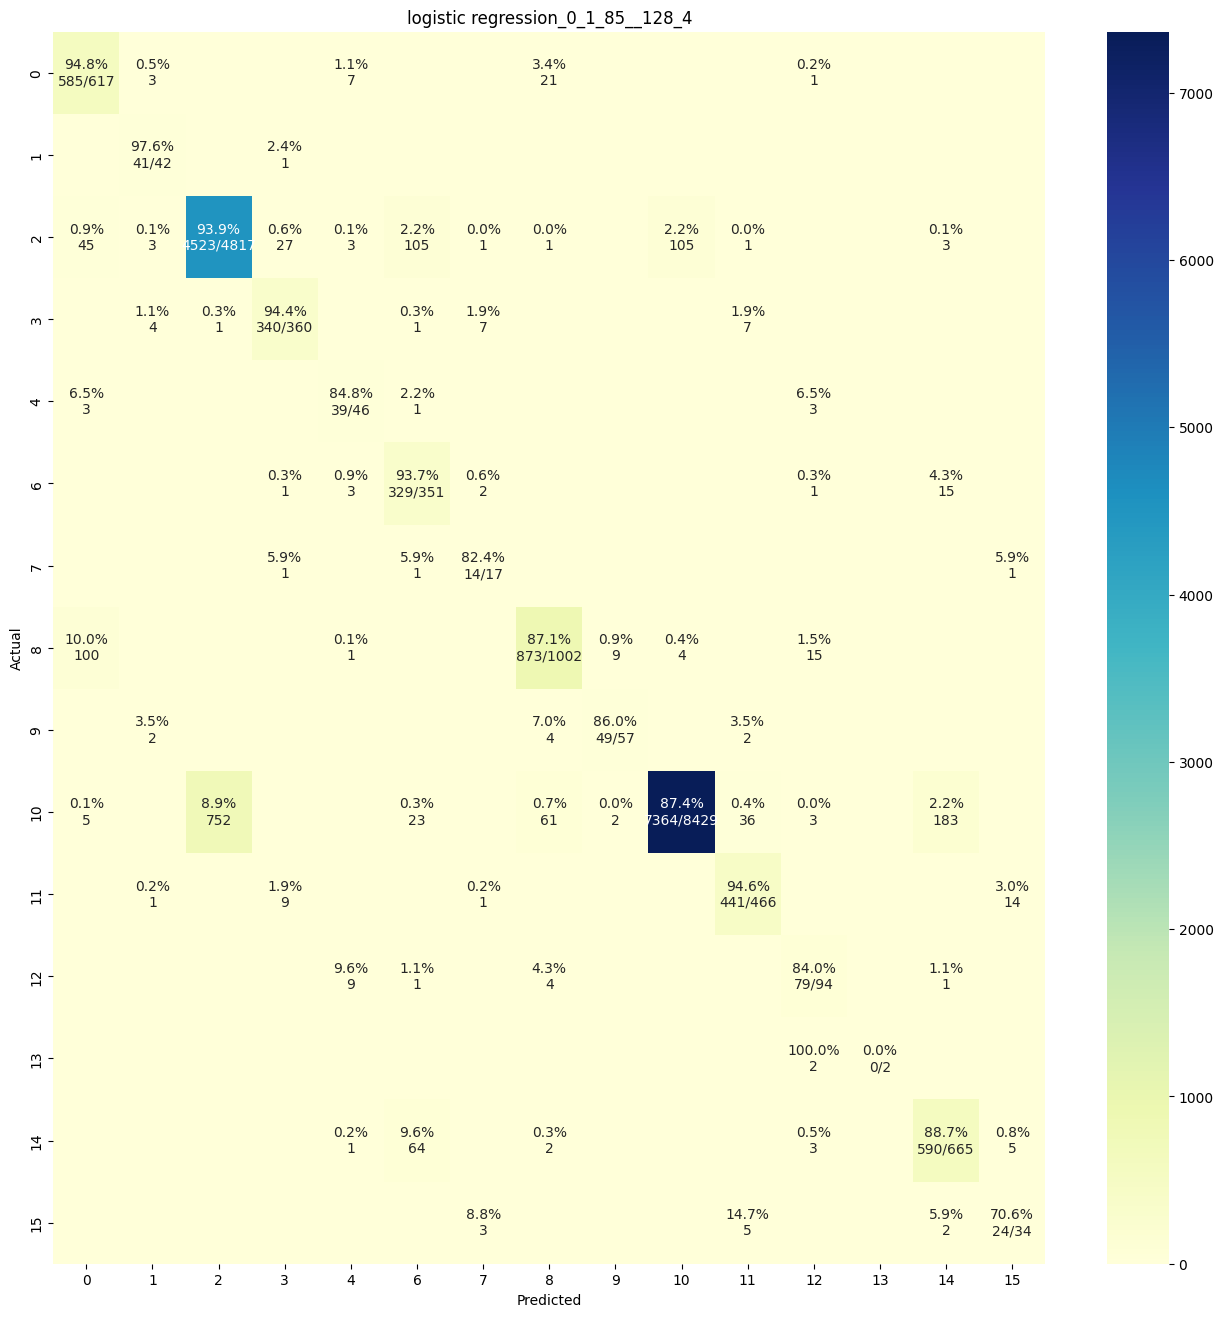

In [20]:
plot_cm(y_test,clf_optimised.predict(X_test))

XG Boost

100%|██████████| 10/10 [23:06<00:00, 138.66s/trial, best loss: -0.9355735023506285]
Best XGBoost Parameters: {'colsample_bytree': 0.8264653372240686, 'gamma': 1.901366610931654, 'learning_rate': 0.11019201929758056, 'max_depth': 11, 'n_estimators': 270, 'reg_alpha': 0.03216582296584258, 'reg_lambda': 0.9900947827219757, 'subsample': 0.7889771634867465}
XGBoost Tuned Accuracy: 0.9378823529411765


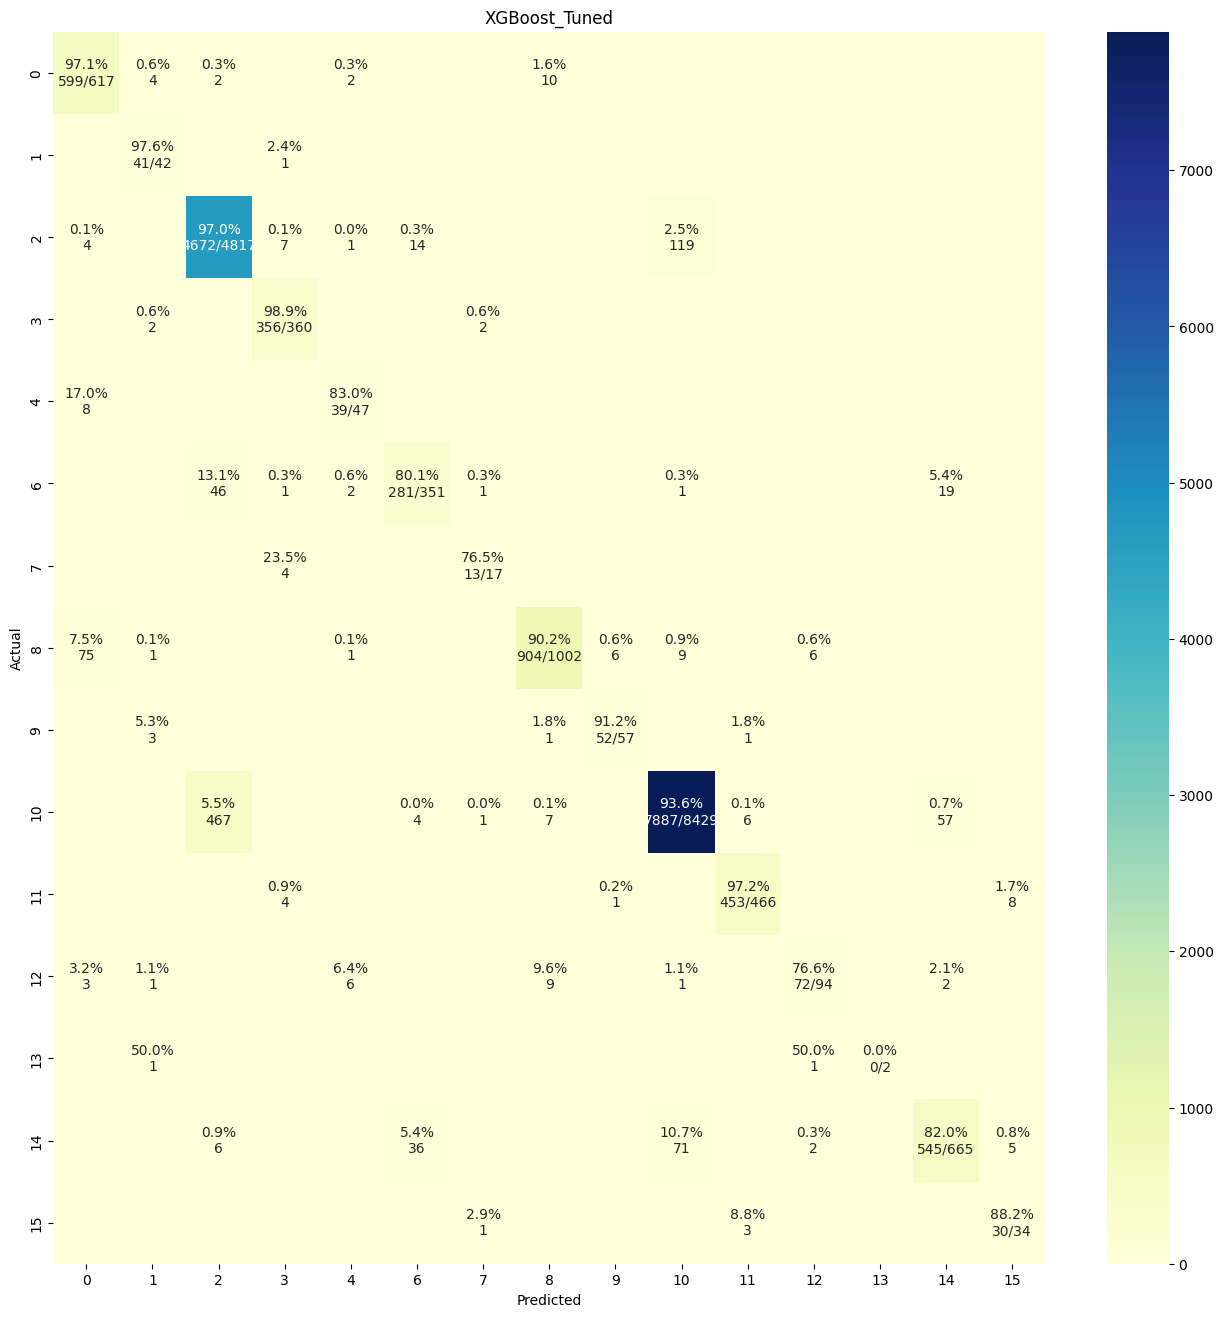

In [21]:
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK, space_eval
from xgboost import XGBClassifier

# Define search space
xgb_space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 300, 10)),
    'max_depth': scope.int(hp.quniform('max_depth', 3, 15, 1)),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Define model and objective
def xgb_model(params):
    clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', **params)
    acc = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=3).mean()
    return {'loss': -acc, 'status': STATUS_OK}

xgb_trials = Trials()
best_xgb = fmin(fn=xgb_model, space=xgb_space, algo=tpe.suggest, max_evals=10, trials=xgb_trials)

best_xgb_params = space_eval(xgb_space, best_xgb)
print("Best XGBoost Parameters:", best_xgb_params)

# Train with best params
xgb_best_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', **best_xgb_params)
xgb_best_clf.fit(X_train, y_train)

# Evaluate
xgb_preds = xgb_best_clf.predict(X_test)
print("XGBoost Tuned Accuracy:", accuracy_score(y_test, xgb_preds))
plot_cm(y_test, xgb_preds, title="XGBoost_Tuned", file_name="xgb_tuned_matrix")


In [22]:
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))



Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       617
           1       0.77      0.98      0.86        42
           2       0.90      0.97      0.93      4817
           3       0.95      0.99      0.97       360
           4       0.76      0.83      0.80        47
           6       0.84      0.80      0.82       351
           7       0.72      0.76      0.74        17
           8       0.97      0.90      0.94      1002
           9       0.88      0.91      0.90        57
          10       0.98      0.94      0.96      8429
          11       0.98      0.97      0.98       466
          12       0.89      0.77      0.82        94
          13       0.00      0.00      0.00         2
          14       0.87      0.82      0.85       665
          15       0.70      0.88      0.78        34

    accuracy                           0.94     17000
   macro avg       0.81      0.83      0.82     17000
w

Random Forest


100%|██████████| 10/10 [20:41<00:00, 124.16s/trial, best loss: -0.9232647041190333]
Best RF Parameters: {'max_depth': 24, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 210}
Random Forest Accuracy: 0.9247058823529412

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       617
           1       0.88      0.83      0.85        42
           2       0.87      0.97      0.92      4817
           3       0.94      0.93      0.93       360
           4       0.80      0.34      0.48        47
           6       0.83      0.71      0.76       351
           7       1.00      0.12      0.21        17
           8       0.96      0.90      0.93      1002
           9       0.88      0.75      0.81        57
          10       0.97      0.93      0.95      8429
          11       0.94      0.95      0.95       466
          12       0.88      0.71      0.79        94
          13     

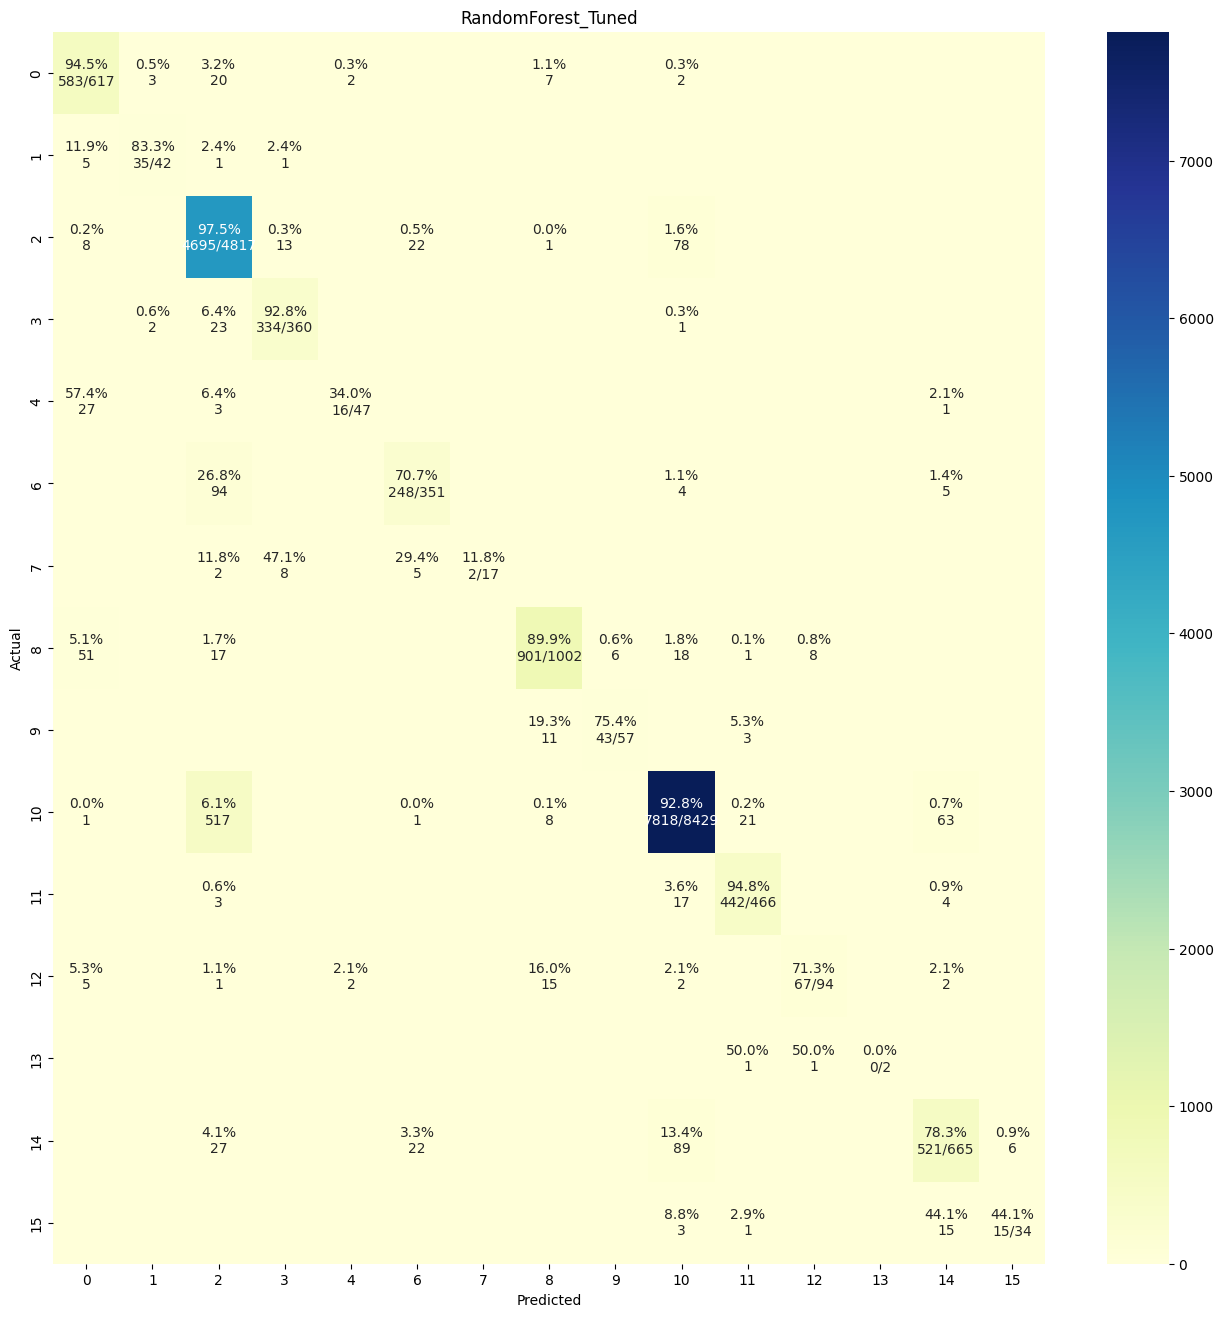

In [23]:
"""Random Forest Classifier"""

from sklearn.ensemble import RandomForestClassifier
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK, space_eval

# Step 1: Define search space
rf_space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 300, 10)),
    'max_depth': scope.int(hp.quniform('max_depth', 5, 30, 1)),
    'min_samples_split': scope.int(hp.quniform('min_samples_split', 2, 10, 1)),
    'min_samples_leaf': scope.int(hp.quniform('min_samples_leaf', 1, 5, 1)),
    'max_features': hp.choice('max_features', ['sqrt', 'log2', None])
}

# Step 2: Objective function
def rf_model(params):
    clf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    acc = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=3).mean()
    return {'loss': -acc, 'status': STATUS_OK}

# Step 3: Run tuning
rf_trials = Trials()
best_rf = fmin(fn=rf_model, space=rf_space, algo=tpe.suggest, max_evals=10, trials=rf_trials)
best_rf_params = space_eval(rf_space, best_rf)
print("Best RF Parameters:", best_rf_params)

# Step 4: Train and predict
rf_best_clf = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
rf_best_clf.fit(X_train, y_train)
rf_preds = rf_best_clf.predict(X_test)

# Step 5: Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_preds))

# Step 6: Confusion matrix plot
plot_cm(y_test, rf_preds, title="RandomForest_Tuned", file_name="rf_tuned_matrix")


In [26]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error
import pandas as pd

# Create a dictionary for easy looping
models_predictions = {
    'Logistic Regression': clf_optimised.predict(X_test),
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds
}

# Storage for results
comparison_results = []

# Loop over bits and models
for bit in range(4):
    y_true_bit = y_test[:, bit]  # True labels for bit i

    for model_name, predictions in models_predictions.items():
        y_pred_bit = predictions[:, bit]  # Predictions for bit i

        acc = accuracy_score(y_true_bit, y_pred_bit)
        f1 = f1_score(y_true_bit, y_pred_bit)
        prec = precision_score(y_true_bit, y_pred_bit)
        rec = recall_score(y_true_bit, y_pred_bit)
        mse = mean_squared_error(y_true_bit, y_pred_bit)

        comparison_results.append({
            'Bit': f'Bit {bit}',
            'Model': model_name,
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'MSE': round(mse, 4)
        })

# Create final comparison DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Display results
print(comparison_df)

# Optionally save to CSV
comparison_df.to_csv('PUF_Model_Comparison_Table.csv', index=False)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

NameError: name 'y_pred_lr' is not defined

SVM

In [ ]:
"""SVM - RBF Kernel"""

from sklearn.svm import SVC
from hyperopt import hp, tpe, fmin, Trials, STATUS_OK, space_eval
from sklearn.model_selection import cross_val_score

# Define hyperparameter space for SVM with RBF kernel
svm_rbf_space = {
    'C': hp.uniform('C', 0.1, 10),
    'gamma': hp.uniform('gamma', 0.0001, 1),
    'kernel': hp.choice('kernel', ['rbf'])
}

# Objective function for Hyperopt
def svm_rbf_model(params):
    clf = SVC(**params)
    acc = cross_val_score(clf, X_train, y_train, scoring='accuracy', cv=3).mean()
    return {'loss': -acc, 'status': STATUS_OK}

# Run hyperparameter tuning
svm_rbf_trials = Trials()
best_svm_rbf = fmin(
    fn=svm_rbf_model,
    space=svm_rbf_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=svm_rbf_trials
)

# Get best parameters and train final model
best_svm_rbf_params = space_eval(svm_rbf_space, best_svm_rbf)
print("Best SVM-RBF Parameters:", best_svm_rbf_params)

svm_rbf_clf = SVC(**best_svm_rbf_params)
svm_rbf_clf.fit(X_train, y_train)

# Make predictions
svm_rbf_preds = svm_rbf_clf.predict(X_test)

# Evaluate
print("SVM-RBF Accuracy:", accuracy_score(y_test, svm_rbf_preds))
print("F1 Score:", f1_score(y_test, svm_rbf_preds, average='weighted'))
print("Precision:", precision_score(y_test, svm_rbf_preds, average='weighted'))
print("Recall:", recall_score(y_test, svm_rbf_preds, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, svm_rbf_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_rbf_preds))

# Plot Confusion Matrix
plot_cm(y_test, svm_rbf_preds, title="SVM_RBF_Tuned", file_name="svm_rbf_tuned_matrix")


  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]